# F1 Track & Race Recommendation System
## CS Machine Learning - Final Project

**Group Members:** Anjali Gudimani, Kapil Hingu, Madhu Chandrika Balram

### Problem Statement

This project aims to identify patterns in Formula 1 race data and develop a system that recommends races based on statistical characteristics. We use race-level features derived from the Ergast F1 API (seasons 2000–2024) and apply multiple machine learning techniques — **Linear Regression**, **Random Forest Regression**, **Logistic Regression (Classification)**, **K-Means Clustering**, and a **Stacking Ensemble** — to predict race excitement and recommend similar races.

### Dataset

- **Source:** Ergast Formula 1 API (api.jolpi.ca/ergast/f1)
- **Scope:** Race results from seasons 2000–2024
- **Processed dataset:** Race-level observations with engineered features

### Target Variables

1. **race_excitement_score** (continuous) — derived from finish position variance, grid position variance, and normalized total points. Used for regression.
2. **high_interest** (binary) — 1 if excitement score > median, 0 otherwise. Used for classification.


## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    StackingRegressor,
    GradientBoostingRegressor
)
from sklearn.cluster import KMeans

# Metrics
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.metrics.pairwise import cosine_similarity

print("All imports successful!")
print(f"pandas {pd.__version__}, numpy {np.__version__}")


All imports successful!
pandas 2.2.2, numpy 2.0.2


## 2. Data Download

We download data from the Ergast F1 API. The API returns paginated results (max 100 per request), so we loop with offsets to get all data.

In [2]:
import requests
from pathlib import Path

BASE_URL = "https://api.jolpi.ca/ergast/f1"
RAW_DIR = Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)


def fetch_json(url):
    """Fetch JSON from URL with error handling."""
    r = requests.get(url, timeout=30)
    if r.status_code != 200:
        raise Exception(f"API request failed: {r.status_code}")
    return r.json()


def download_races():
    """Download all F1 races (1950-present)."""
    rows = []
    limit, offset = 100, 0

    while True:
        url = f"{BASE_URL}/races.json?limit={limit}&offset={offset}"
        data = fetch_json(url)
        races = data["MRData"]["RaceTable"]["Races"]
        if not races:
            break

        for r in races:
            rows.append({
                "raceId": f"{r['season']}_{r['round']}",
                "season": int(r["season"]),
                "round": int(r["round"]),
                "raceName": r["raceName"],
                "date": r["date"],
                "circuitId": r["Circuit"]["circuitId"],
                "circuitName": r["Circuit"]["circuitName"],
                "country": r["Circuit"]["Location"]["country"],
                "lat": float(r["Circuit"]["Location"]["lat"]),
                "lng": float(r["Circuit"]["Location"]["long"]),
            })
        offset += limit

    df = pd.DataFrame(rows)
    df.to_csv(RAW_DIR / "races.csv", index=False)
    print(f"Saved {len(df)} races")
    return df


def download_circuits():
    """Download all F1 circuits."""
    url = f"{BASE_URL}/circuits.json?limit=1000"
    data = fetch_json(url)
    rows = []
    for c in data["MRData"]["CircuitTable"]["Circuits"]:
        rows.append({
            "circuitId": c["circuitId"],
            "circuitName": c["circuitName"],
            "country": c["Location"]["country"],
            "lat": float(c["Location"]["lat"]),
            "lng": float(c["Location"]["long"]),
        })
    df = pd.DataFrame(rows)
    df.to_csv(RAW_DIR / "circuits.csv", index=False)
    print(f"Saved {len(df)} circuits")
    return df


def download_results(start_year=2000, end_year=2024):
    """
    Download race results WITH PROPER PAGINATION.
    The API returns max 100 results per request.
    """
    rows = []
    for year in range(start_year, end_year + 1):
        offset = 0
        limit = 100
        while True:
            url = f"{BASE_URL}/{year}/results.json?limit={limit}&offset={offset}"
            data = fetch_json(url)
            races = data["MRData"]["RaceTable"]["Races"]
            total = int(data["MRData"]["total"])

            if not races:
                break

            for race in races:
                season = int(race["season"])
                rnd = int(race["round"])
                race_id = f"{season}_{rnd}"
                for res in race["Results"]:
                    rows.append({
                        "raceId": race_id,
                        "season": season,
                        "round": rnd,
                        "driverId": res["Driver"]["driverId"],
                        "constructorId": res["Constructor"]["constructorId"],
                        "grid": int(res["grid"]),
                        "positionOrder": int(res.get("position", 0)),
                        "points": float(res["points"]),
                        "status": res["status"],
                    })

            offset += limit
            if offset >= total:
                break

        print(f"  Downloaded {year}")

    df = pd.DataFrame(rows)
    df.to_csv(RAW_DIR / "results.csv", index=False)
    print(f"Saved {len(df)} result rows")
    return df

if (RAW_DIR / "results.csv").exists():
    print("Data files already exist in data/raw/. Loading from disk.")
    print("(Delete data/raw/ folder and re-run this cell to re-download)")
else:
    print("Downloading data from Ergast API...")
    download_races()
    download_circuits()
    download_results(2000, 2024)
    print("\nDownload complete!")


Data files already exist in data/raw/. Loading from disk.
(Delete data/raw/ folder and re-run this cell to re-download)


## 3. Load Raw Data

In [3]:
# Load raw data
races_raw = pd.read_csv("data/raw/races.csv")
results_raw = pd.read_csv("data/raw/results.csv")
circuits_raw = pd.read_csv("data/raw/circuits.csv")

print("=== Raw Data Shapes ===")
print(f"Races:    {races_raw.shape}")
print(f"Results:  {results_raw.shape}")
print(f"Circuits: {circuits_raw.shape}")

print("\n=== Races (first 5 rows) ===")
races_raw.head()


=== Raw Data Shapes ===
Races:    (1173, 10)
Results:  (2500, 9)
Circuits: (78, 5)

=== Races (first 5 rows) ===


,raceId,season,round,raceName,date,circuitId,circuitName,country,lat,lng
0,1950_1,1950,1,British Grand Prix,1950-05-13,silverstone,Silverstone Circuit,UK,52.0786,-1.01694
1,1950_2,1950,2,Monaco Grand Prix,1950-05-21,monaco,Circuit de Monaco,Monaco,43.7347,7.42056
2,1950_3,1950,3,Indianapolis 500,1950-05-30,indianapolis,Indianapolis Motor Speedway,USA,39.7950,-86.23470
3,1950_4,1950,4,Swiss Grand Prix,1950-06-04,bremgarten,Circuit Bremgarten,Switzerland,46.9589,7.40194
4,1950_5,1950,5,Belgian Grand Prix,1950-06-18,spa,Circuit de Spa-Francorchamps,Belgium,50.4372,5.97139


In [4]:
print("=== Results (first 5 rows) ===")
results_raw.head()


=== Results (first 5 rows) ===


,raceId,season,round,driverId,constructorId,grid,positionOrder,points,status
0,2000_1,2000,1,michael_schumacher,ferrari,3,1,10.0,Finished
1,2000_1,2000,1,barrichello,ferrari,4,2,6.0,Finished
2,2000_1,2000,1,ralf_schumacher,williams,11,3,4.0,Finished
3,2000_1,2000,1,villeneuve,bar,8,4,3.0,Finished
4,2000_1,2000,1,fisichella,benetton,9,5,2.0,Finished


In [5]:
print("=== Circuits (first 5 rows) ===")
circuits_raw.head()


=== Circuits (first 5 rows) ===


,circuitId,circuitName,country,lat,lng
0,adelaide,Adelaide Street Circuit,Australia,-34.9272,138.61700
1,ain-diab,Ain Diab,Morocco,33.5786,-7.68750
2,aintree,Aintree,UK,53.4769,-2.94056
3,albert_park,Albert Park Grand Prix Circuit,Australia,-37.8497,144.96800
4,americas,Circuit of the Americas,USA,30.1328,-97.64110


## 4. Data Preprocessing

We aggregate individual race results up to the race level, creating statistical features like number of drivers, average positions, and variance measures. Then we engineer our target variables.


In [6]:
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Step 1: Aggregate results per race
race_stats = results_raw.groupby("raceId").agg(
    num_drivers=("driverId", "nunique"),
    total_points=("points", "sum"),
    avg_grid_position=("grid", "mean"),
    avg_finish_position=("positionOrder", "mean"),
    grid_variance=("grid", "var"),
    finish_variance=("positionOrder", "var"),
    points_variance=("points", "var"),
).reset_index()

print(f"Race-level stats: {race_stats.shape[0]} races, {race_stats.shape[1]} columns")
race_stats.head()


Race-level stats: 128 races, 8 columns


,raceId,num_drivers,total_points,avg_grid_position,avg_finish_position,grid_variance,finish_variance,points_variance
0,2000_1,22,26.0,11.500000,11.5,42.166667,42.166667,6.441558
1,2000_2,22,26.0,9.545455,11.5,41.212121,42.166667,6.441558
2,2000_3,22,26.0,11.500000,11.5,42.166667,42.166667,6.441558
3,2000_4,22,26.0,11.500000,11.5,42.166667,42.166667,6.441558
4,2000_5,12,26.0,8.166667,6.5,31.060606,13.000000,9.969697


In [7]:
# Step 2: Merge with race info (name, date, circuit, location)
race_df = races_raw.merge(race_stats, on="raceId", how="inner")
print(f"After merge: {race_df.shape[0]} races with {race_df.shape[1]} columns")

# Step 3: Engineer features
race_df["competitiveness_score"] = (
    race_df["finish_variance"].fillna(0) + race_df["grid_variance"].fillna(0)
)

race_df["total_points_norm"] = (
    race_df["total_points"] - race_df["total_points"].min()
) / (race_df["total_points"].max() - race_df["total_points"].min())

# Step 4: Create TARGET variables
race_df["race_excitement_score"] = (
    race_df["finish_variance"].fillna(0)
    + race_df["grid_variance"].fillna(0)
    + race_df["total_points_norm"]
)

median_score = race_df["race_excitement_score"].median()
race_df["high_interest"] = (race_df["race_excitement_score"] > median_score).astype(int)

# Step 5: Save
race_df.to_csv(OUT_DIR / "race_features.csv", index=False)

print(f"\nFinal dataset: {race_df.shape[0]} rows, {race_df.shape[1]} columns")
print(f"Excitement score — min: {race_df['race_excitement_score'].min():.2f}, "
      f"max: {race_df['race_excitement_score'].max():.2f}, "
      f"median: {median_score:.2f}")
print(f"\nHigh interest distribution:")
print(race_df["high_interest"].value_counts())
print(f"\nColumns: {list(race_df.columns)}")


After merge: 128 races with 17 columns

Final dataset: 128 rows, 21 columns
Excitement score — min: 0.08, max: 100.99, median: 71.00

High interest distribution:
high_interest
0    74
1    54
Name: count, dtype: int64

Columns: ['raceId', 'season', 'round', 'raceName', 'date', 'circuitId', 'circuitName', 'country', 'lat', 'lng', 'num_drivers', 'total_points', 'avg_grid_position', 'avg_finish_position', 'grid_variance', 'finish_variance', 'points_variance', 'competitiveness_score', 'total_points_norm', 'race_excitement_score', 'high_interest']


## 5. Exploratory Data Analysis (EDA)

Before modeling, we explore data distributions, correlations, and patterns.


In [8]:
df = pd.read_csv("data/processed/race_features.csv")
df = df.fillna(0)

print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nSeasons covered: {df['season'].min()} to {df['season'].max()}")
print(f"Unique circuits: {df['circuitId'].nunique()}")
print(f"Unique countries: {df['country'].nunique()}")
print(f"\n=== Descriptive Statistics ===")
df.describe().round(2)


Dataset: 128 rows, 21 columns

Seasons covered: 2000 to 2024
Unique circuits: 19
Unique countries: 19

=== Descriptive Statistics ===


,season,round,lat,lng,num_drivers,total_points,avg_grid_position,avg_finish_position,grid_variance,finish_variance,points_variance,competitiveness_score,total_points_norm,race_excitement_score,high_interest
count,128.00,128.00,128.00,128.00,128.00,128.00,128.00,128.00,128.00,128.00,128.00,128.00,128.00,128.00,128.00
mean,2012.06,3.07,17.23,59.48,19.53,73.19,10.34,10.27,36.55,35.05,34.63,71.60,0.66,72.26,0.42
std,7.26,1.48,30.39,61.27,4.44,33.21,1.83,2.22,8.99,10.95,22.35,19.45,0.40,19.51,0.50
min,2000.00,1.00,-37.85,-80.24,1.00,18.00,2.50,1.00,0.00,0.00,0.00,0.00,0.00,0.08,0.00
25%,2006.00,2.00,2.76,7.30,20.00,39.00,10.50,10.50,35.00,35.00,9.42,70.00,0.25,70.25,0.00
50%,2012.00,3.00,26.03,50.51,20.00,101.00,10.50,10.50,35.00,35.00,48.43,70.00,0.99,71.00,0.00
75%,2018.00,4.00,41.57,121.22,22.00,101.00,11.50,11.50,42.17,42.17,54.16,84.33,0.99,84.58,1.00
max,2024.00,6.00,52.08,144.97,24.00,102.00,12.50,12.50,50.00,50.00,62.63,100.00,1.00,100.99,1.00


In [9]:
# Missing values check
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")


=== Missing Values ===
No missing values!


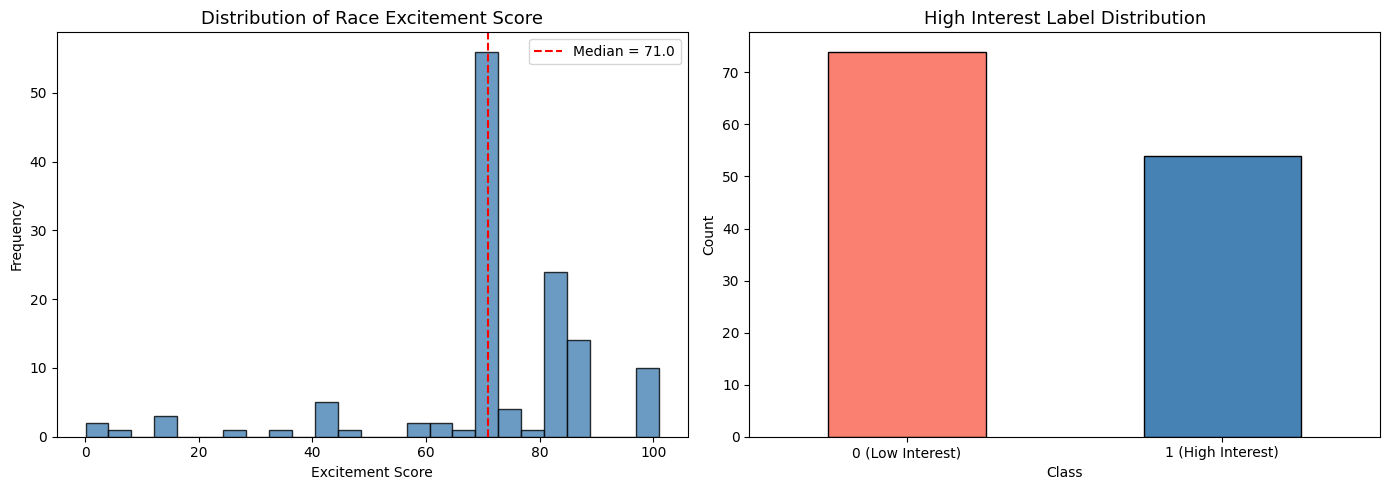

In [10]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["race_excitement_score"], bins=25, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].set_title("Distribution of Race Excitement Score", fontsize=13)
axes[0].set_xlabel("Excitement Score")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df["race_excitement_score"].median(), color='red', linestyle='--',
                label=f'Median = {df["race_excitement_score"].median():.1f}')
axes[0].legend()

colors = ['salmon', 'steelblue']
df["high_interest"].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title("High Interest Label Distribution", fontsize=13)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(['0 (Low Interest)', '1 (High Interest)'], rotation=0)

plt.tight_layout()
plt.show()


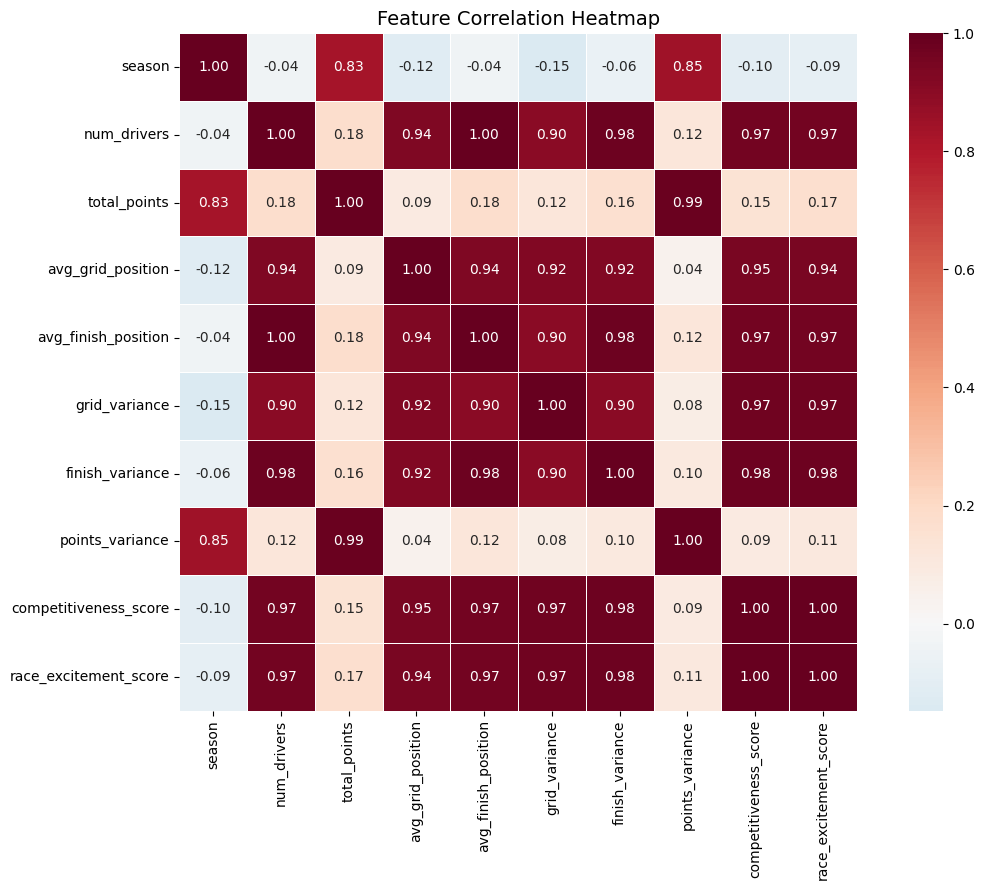

In [11]:
# Correlation heatmap
numeric_cols = [
    "season", "num_drivers", "total_points", "avg_grid_position",
    "avg_finish_position", "grid_variance", "finish_variance",
    "points_variance", "competitiveness_score", "race_excitement_score"
]

fig, ax = plt.subplots(figsize=(12, 9))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()


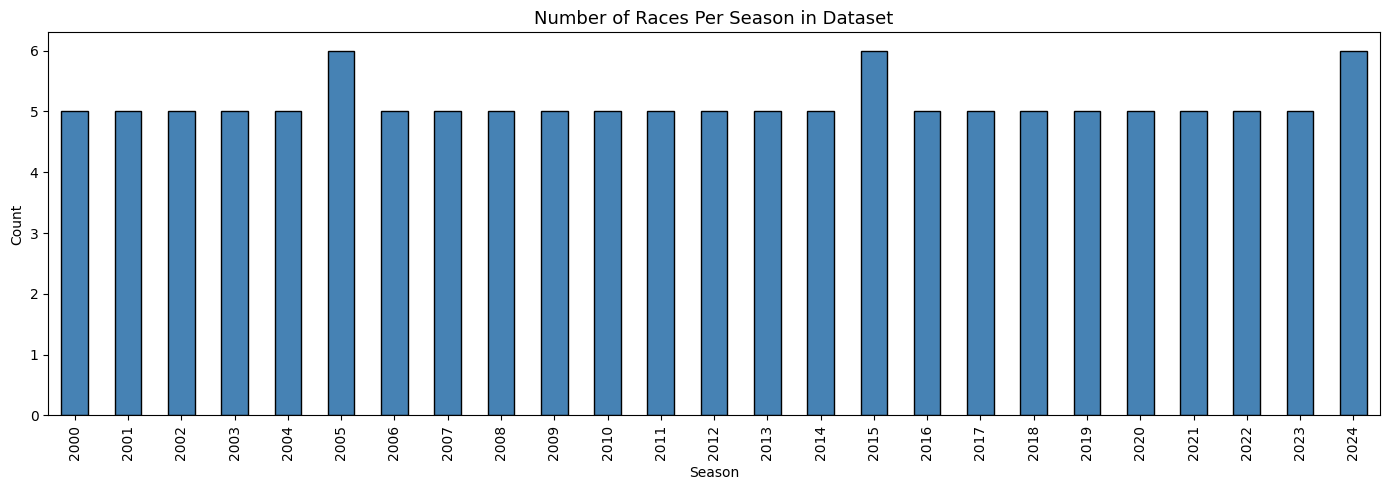

In [12]:
# Races per season
fig, ax = plt.subplots(figsize=(14, 5))
races_per_season = df.groupby("season").size()
races_per_season.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title("Number of Races Per Season in Dataset", fontsize=13)
ax.set_xlabel("Season")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


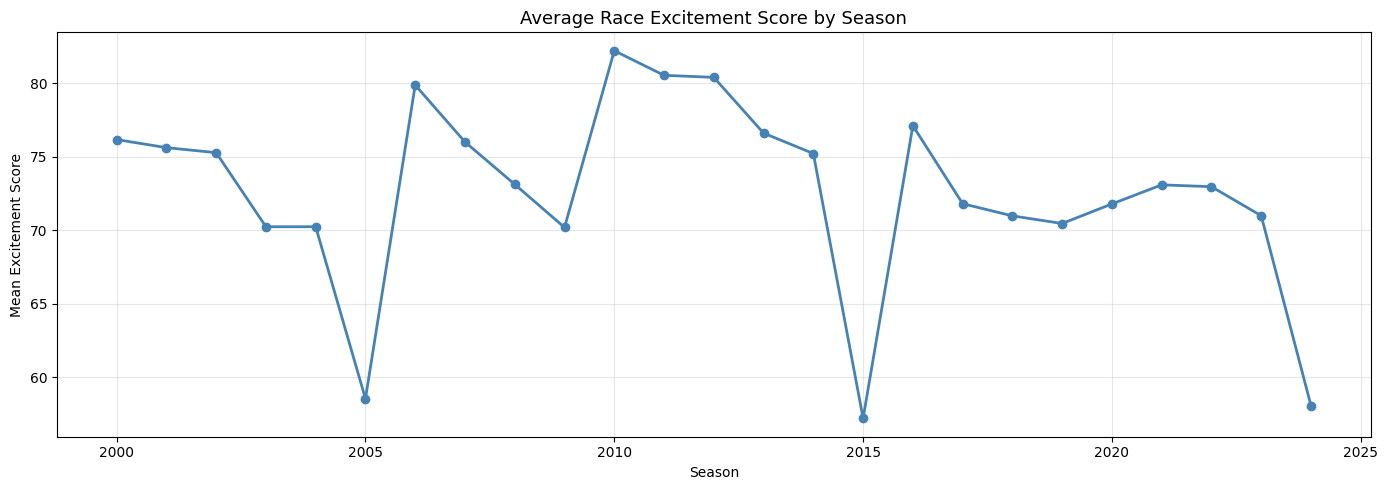

In [13]:
# Average excitement by season
fig, ax = plt.subplots(figsize=(14, 5))
df.groupby("season")["race_excitement_score"].mean().plot(
    kind='line', marker='o', ax=ax, color='steelblue', linewidth=2)
ax.set_title("Average Race Excitement Score by Season", fontsize=13)
ax.set_xlabel("Season")
ax.set_ylabel("Mean Excitement Score")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
# Top 10 most exciting races
top10 = df.nlargest(10, "race_excitement_score")[
    ["season", "raceName", "country", "num_drivers", "race_excitement_score"]
]
print("=== Top 10 Most Exciting Races ===")
top10


=== Top 10 Most Exciting Races ===


,season,raceName,country,num_drivers,race_excitement_score
51,2010,Bahrain Grand Prix,Bahrain,24,100.988095
52,2010,Australian Grand Prix,Australia,24,100.988095
53,2010,Malaysian Grand Prix,Malaysia,24,100.988095
54,2010,Chinese Grand Prix,China,24,100.988095
57,2011,Malaysian Grand Prix,Malaysia,24,100.988095
58,2011,Chinese Grand Prix,China,24,100.988095
59,2011,Turkish Grand Prix,Turkey,24,100.988095
62,2012,Malaysian Grand Prix,Malaysia,24,100.988095
63,2012,Chinese Grand Prix,China,24,100.988095
64,2012,Bahrain Grand Prix,Bahrain,24,100.988095


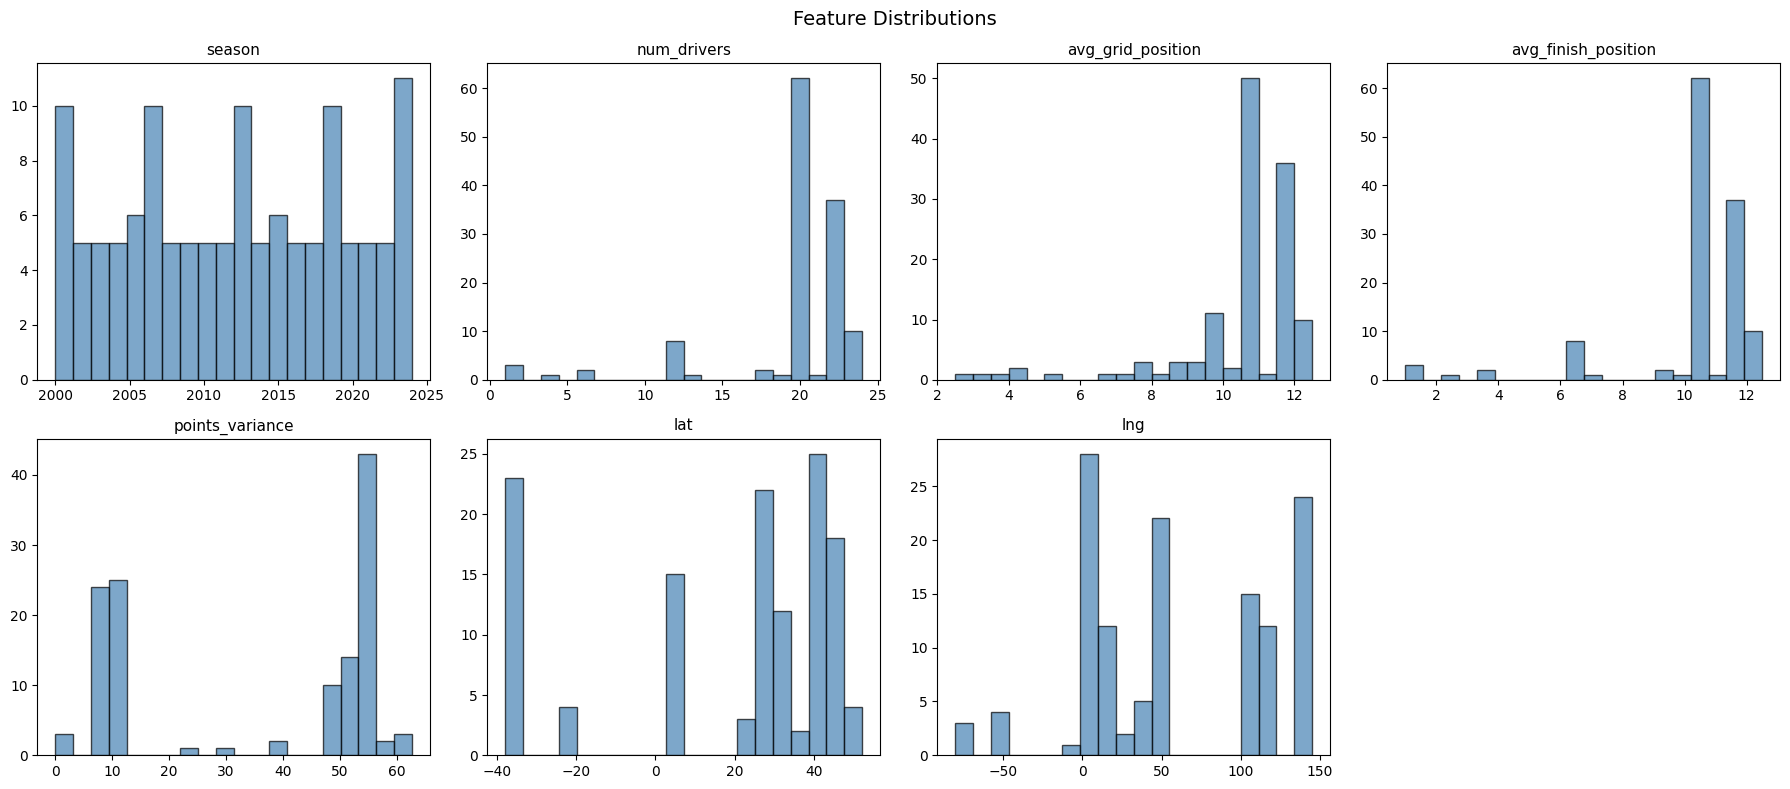

In [15]:
# Feature distributions
feature_cols = ["season", "num_drivers", "avg_grid_position",
                "avg_finish_position", "points_variance", "lat", "lng"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
axes[-1].axis('off')
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()


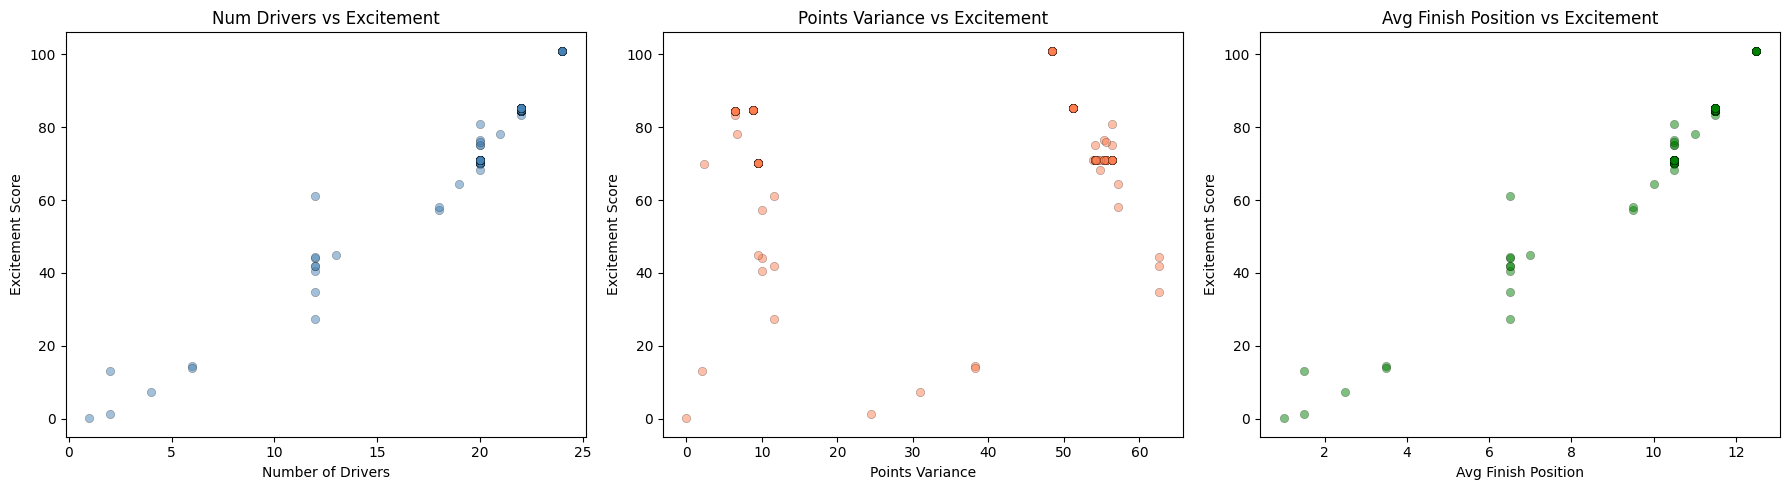

In [16]:
# Scatter plots: key features vs target
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df["num_drivers"], df["race_excitement_score"],
                alpha=0.5, c='steelblue', edgecolors='black', linewidths=0.3)
axes[0].set_xlabel("Number of Drivers")
axes[0].set_ylabel("Excitement Score")
axes[0].set_title("Num Drivers vs Excitement")

axes[1].scatter(df["points_variance"], df["race_excitement_score"],
                alpha=0.5, c='coral', edgecolors='black', linewidths=0.3)
axes[1].set_xlabel("Points Variance")
axes[1].set_ylabel("Excitement Score")
axes[1].set_title("Points Variance vs Excitement")

axes[2].scatter(df["avg_finish_position"], df["race_excitement_score"],
                alpha=0.5, c='green', edgecolors='black', linewidths=0.3)
axes[2].set_xlabel("Avg Finish Position")
axes[2].set_ylabel("Excitement Score")
axes[2].set_title("Avg Finish Position vs Excitement")

plt.tight_layout()
plt.show()


## 6. Feature Selection and Data Preparation

**Features used for modeling:**

1- season : Year of the race 

2-num_drivers : Number of drivers participating 

3-avg_grid_position : Mean starting grid position 

4-avg_finish_position : Mean finishing position 

5-points_variance : Variance in points scored 

6-lat : Circuit latitude 

7-lng : Circuit longitude 

Note: We exclude `grid_variance`, `finish_variance`, and `competitiveness_score` from features because they are used directly in computing the target (`race_excitement_score = finish_variance + grid_variance + total_points_norm`). Including them would cause data leakage.


In [17]:
# Prepare features and targets
feature_cols = [
    "season", "num_drivers", "avg_grid_position",
    "avg_finish_position", "points_variance", "lat", "lng"
]

X = df[feature_cols]
y_reg = df["race_excitement_score"]   
y_clf = df["high_interest"]          

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (80/20) — SAME split for all models
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)
_, _, y_clf_train, y_clf_test = train_test_split(
    X_scaled, y_clf, test_size=0.2, random_state=42
)

print(f"Feature matrix shape: {X.shape}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"\nRegression target stats — mean: {y_reg.mean():.2f}, std: {y_reg.std():.2f}")
print(f"Classification target — 0: {(y_clf==0).sum()}, 1: {(y_clf==1).sum()}")


Feature matrix shape: (128, 7)
Training set: 102 samples
Test set:     26 samples

Regression target stats — mean: 72.26, std: 19.51
Classification target — 0: 74, 1: 54


## 7. Model 1: Linear Regression

A baseline model for predicting race excitement score.


In [18]:
# Train
lr_model = LinearRegression()
lr_model.fit(X_train, y_reg_train)

# --- TRAINING results ---
lr_train_pred = lr_model.predict(X_train)
lr_train_mse = mean_squared_error(y_reg_train, lr_train_pred)
lr_train_mae = mean_absolute_error(y_reg_train, lr_train_pred)
lr_train_r2  = r2_score(y_reg_train, lr_train_pred)

# --- TEST results ---
lr_test_pred = lr_model.predict(X_test)
lr_test_mse = mean_squared_error(y_reg_test, lr_test_pred)
lr_test_mae = mean_absolute_error(y_reg_test, lr_test_pred)
lr_test_r2  = r2_score(y_reg_test, lr_test_pred)

# --- CROSS-VALIDATION ---
lr_cv = cross_val_score(lr_model, X_scaled, y_reg, cv=5, scoring='r2')

print("=" * 55)
print("  MODEL 1: LINEAR REGRESSION")
print("=" * 55)
print(f"\n  TRAINING SET:")
print(f"    MSE:  {lr_train_mse:.4f}")
print(f"    MAE:  {lr_train_mae:.4f}")
print(f"    R²:   {lr_train_r2:.4f}")
print(f"\n  TEST SET:")
print(f"    MSE:  {lr_test_mse:.4f}")
print(f"    MAE:  {lr_test_mae:.4f}")
print(f"    R²:   {lr_test_r2:.4f}")
print(f"\n  5-Fold CV R²: {lr_cv.round(4)} → Mean: {lr_cv.mean():.4f}")


  MODEL 1: LINEAR REGRESSION

  TRAINING SET:
    MSE:  18.1000
    MAE:  3.2568
    R²:   0.9443

  TEST SET:
    MSE:  16.2460
    MAE:  3.1611
    R²:   0.9704

  5-Fold CV R²: [0.8228 0.8995 0.9429 0.9103 0.9075] → Mean: 0.8966


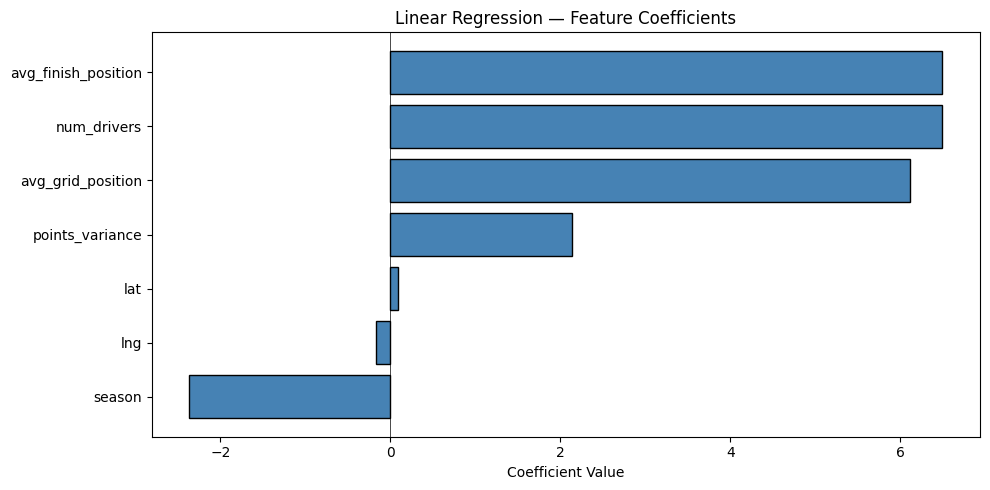

In [19]:
# Coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue', edgecolor='black')
ax.set_title("Linear Regression — Feature Coefficients")
ax.set_xlabel("Coefficient Value")
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


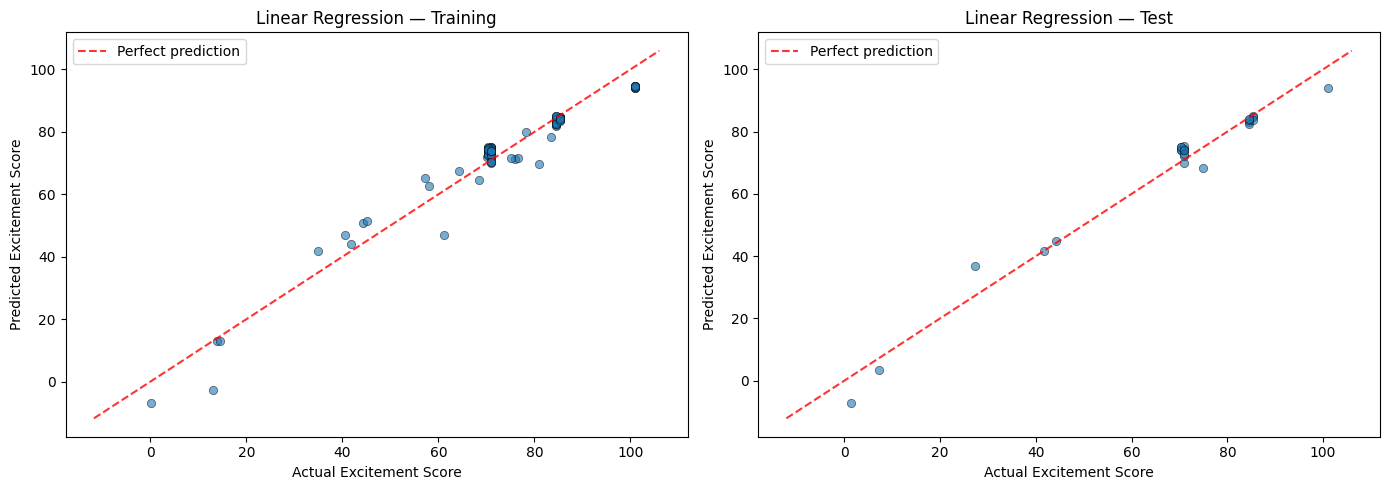

In [20]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, actuals, title in [
    (axes[0], lr_train_pred, y_reg_train, "Training"),
    (axes[1], lr_test_pred, y_reg_test, "Test")
]:
    ax.scatter(actuals, preds, alpha=0.6, edgecolors='black', linewidths=0.5)
    mn = min(actuals.min(), preds.min()) - 5
    mx = max(actuals.max(), preds.max()) + 5
    ax.plot([mn, mx], [mn, mx], 'r--', alpha=0.8, label='Perfect prediction')
    ax.set_xlabel("Actual Excitement Score")
    ax.set_ylabel("Predicted Excitement Score")
    ax.set_title(f"Linear Regression — {title}")
    ax.legend()
plt.tight_layout()
plt.show()


## 8. Model 2: Random Forest Regression

An ensemble of 200 decision trees for non-linear prediction.


In [21]:
# Train
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_reg_train)

# TRAINING
rf_train_pred = rf_model.predict(X_train)
rf_train_mse = mean_squared_error(y_reg_train, rf_train_pred)
rf_train_mae = mean_absolute_error(y_reg_train, rf_train_pred)
rf_train_r2  = r2_score(y_reg_train, rf_train_pred)

# TEST
rf_test_pred = rf_model.predict(X_test)
rf_test_mse = mean_squared_error(y_reg_test, rf_test_pred)
rf_test_mae = mean_absolute_error(y_reg_test, rf_test_pred)
rf_test_r2  = r2_score(y_reg_test, rf_test_pred)

# CV
rf_cv = cross_val_score(rf_model, X_scaled, y_reg, cv=5, scoring='r2')

print("=" * 55)
print("  MODEL 2: RANDOM FOREST REGRESSION")
print("=" * 55)
print(f"\n  TRAINING SET:")
print(f"    MSE:  {rf_train_mse:.4f}")
print(f"    MAE:  {rf_train_mae:.4f}")
print(f"    R²:   {rf_train_r2:.4f}")
print(f"\n  TEST SET:")
print(f"    MSE:  {rf_test_mse:.4f}")
print(f"    MAE:  {rf_test_mae:.4f}")
print(f"    R²:   {rf_test_r2:.4f}")
print(f"\n  5-Fold CV R²: {rf_cv.round(4)} → Mean: {rf_cv.mean():.4f}")


  MODEL 2: RANDOM FOREST REGRESSION

  TRAINING SET:
    MSE:  1.4950
    MAE:  0.4459
    R²:   0.9954

  TEST SET:
    MSE:  19.3422
    MAE:  1.8349
    R²:   0.9647

  5-Fold CV R²: [0.9545 0.9427 0.9804 0.9825 0.9294] → Mean: 0.9579


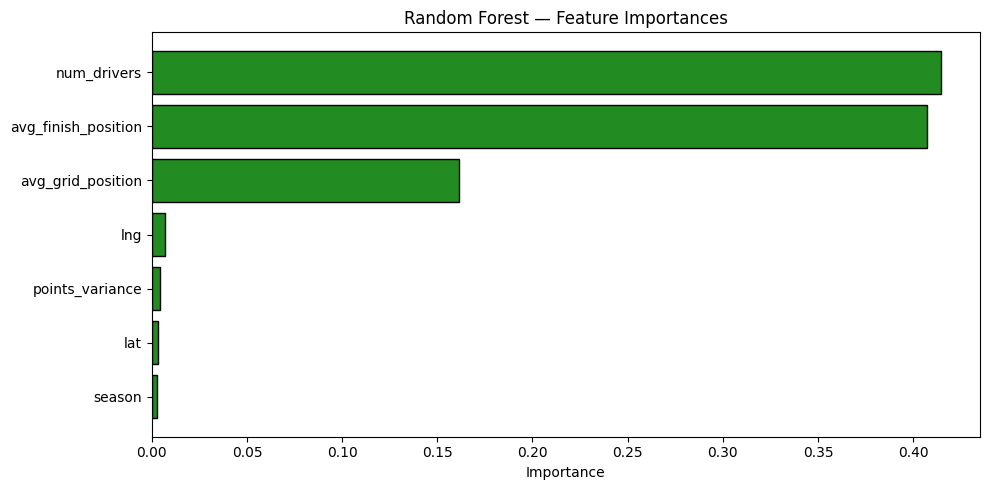

In [22]:
# Feature importance
imp_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(imp_df['Feature'], imp_df['Importance'], color='forestgreen', edgecolor='black')
ax.set_title("Random Forest — Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


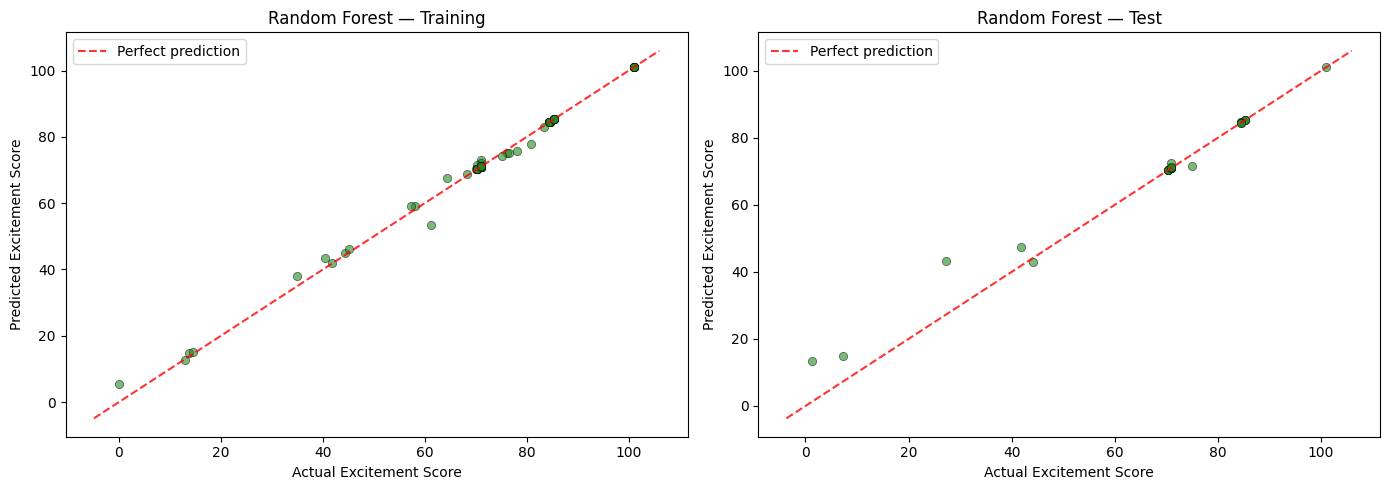

In [23]:
# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, actuals, title in [
    (axes[0], rf_train_pred, y_reg_train, "Training"),
    (axes[1], rf_test_pred, y_reg_test, "Test")
]:
    ax.scatter(actuals, preds, alpha=0.6, edgecolors='black', linewidths=0.5, c='forestgreen')
    mn = min(actuals.min(), preds.min()) - 5
    mx = max(actuals.max(), preds.max()) + 5
    ax.plot([mn, mx], [mn, mx], 'r--', alpha=0.8, label='Perfect prediction')
    ax.set_xlabel("Actual Excitement Score")
    ax.set_ylabel("Predicted Excitement Score")
    ax.set_title(f"Random Forest — {title}")
    ax.legend()
plt.tight_layout()
plt.show()


## 9. Model 3: Logistic Regression (Classification)

Binary classification to predict high-interest (1) vs low-interest (0) races.


In [24]:
# Train
clf_model = LogisticRegression(max_iter=2000, random_state=42)
clf_model.fit(X_train, y_clf_train)

# TRAINING
clf_train_pred = clf_model.predict(X_train)
clf_train_acc  = accuracy_score(y_clf_train, clf_train_pred)

# TEST
clf_test_pred = clf_model.predict(X_test)
clf_test_acc  = accuracy_score(y_clf_test, clf_test_pred)

# CV
clf_cv = cross_val_score(clf_model, X_scaled, y_clf, cv=5, scoring='accuracy')

print("=" * 55)
print("  MODEL 3: LOGISTIC REGRESSION (CLASSIFICATION)")
print("=" * 55)

print(f"\n  TRAINING SET — Accuracy: {clf_train_acc:.4f}")
print(classification_report(y_clf_train, clf_train_pred, target_names=['Low Interest', 'High Interest']))

print(f"  TEST SET — Accuracy: {clf_test_acc:.4f}")
print(classification_report(y_clf_test, clf_test_pred, target_names=['Low Interest', 'High Interest']))

print(f"  5-Fold CV Accuracy: {clf_cv.round(4)} → Mean: {clf_cv.mean():.4f}")


  MODEL 3: LOGISTIC REGRESSION (CLASSIFICATION)

  TRAINING SET — Accuracy: 0.9412
               precision    recall  f1-score   support

 Low Interest       0.92      0.98      0.95        57
High Interest       0.98      0.89      0.93        45

     accuracy                           0.94       102
    macro avg       0.95      0.94      0.94       102
 weighted avg       0.94      0.94      0.94       102

  TEST SET — Accuracy: 0.9615
               precision    recall  f1-score   support

 Low Interest       0.94      1.00      0.97        17
High Interest       1.00      0.89      0.94         9

     accuracy                           0.96        26
    macro avg       0.97      0.94      0.96        26
 weighted avg       0.96      0.96      0.96        26

  5-Fold CV Accuracy: [0.8077 1.     1.     1.     0.76  ] → Mean: 0.9135


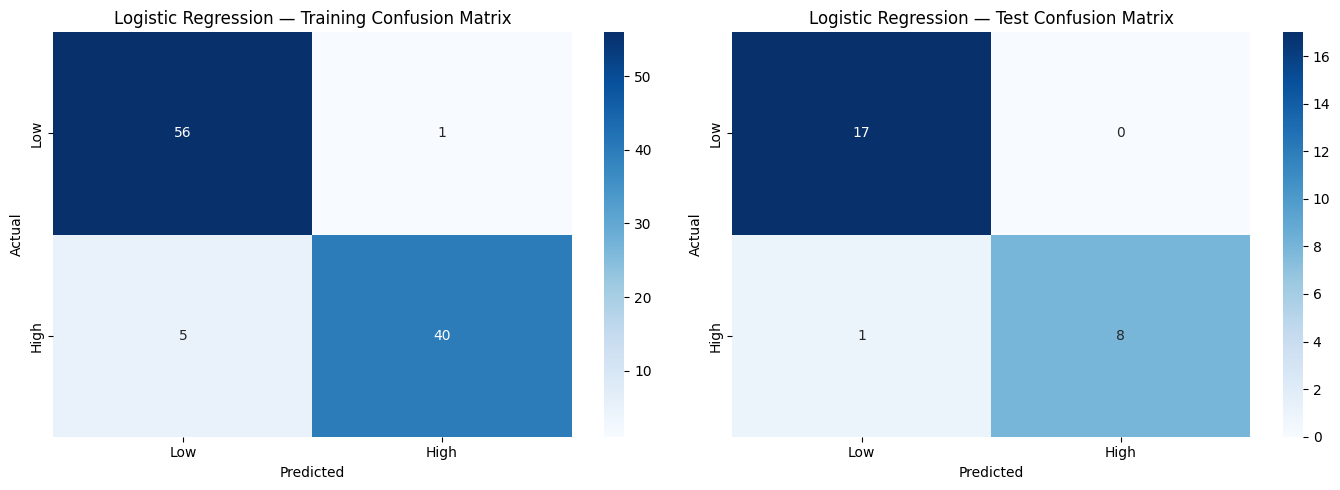

In [25]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, actuals, title in [
    (axes[0], clf_train_pred, y_clf_train, "Training"),
    (axes[1], clf_test_pred, y_clf_test, "Test")
]:
    cm = confusion_matrix(actuals, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Logistic Regression — {title} Confusion Matrix")

plt.tight_layout()
plt.show()


## 10. Model 4: K-Means Clustering

Unsupervised clustering to discover natural groupings of races.


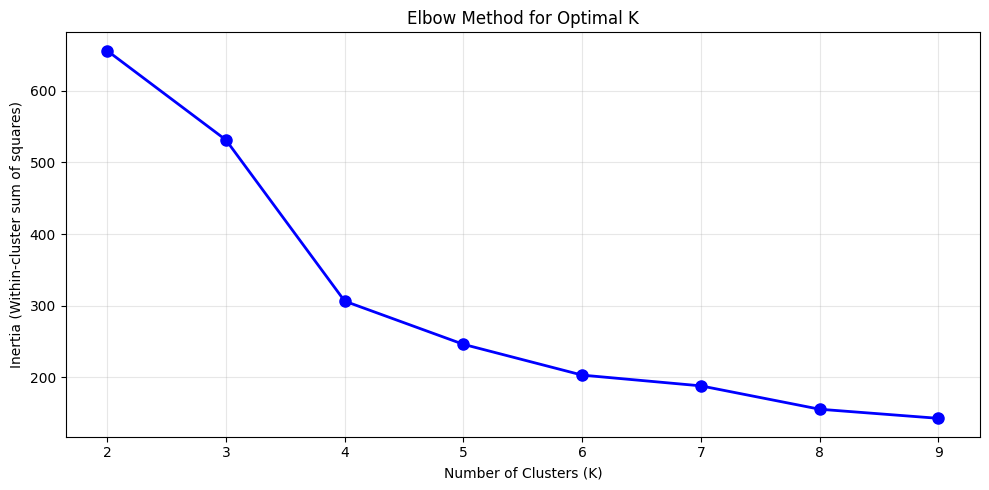

The elbow suggests K=3 as a reasonable choice.


In [26]:
# Elbow method to find optimal K
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (Within-cluster sum of squares)")
ax.set_title("Elbow Method for Optimal K")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("The elbow suggests K=3 as a reasonable choice.")


In [27]:
# Fit final KMeans with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)
df["cluster"] = clusters

print("=" * 55)
print("  MODEL 4: K-MEANS CLUSTERING (K=3)")
print("=" * 55)

print(f"\n  Cluster sizes:")
for c in sorted(df["cluster"].unique()):
    print(f"    Cluster {c}: {(df['cluster']==c).sum()} races")

print(f"\n  === Cluster Profiles (mean values) ===")
cluster_profiles = df.groupby("cluster")[
    feature_cols + ["race_excitement_score"]
].mean().round(2)
print(cluster_profiles.to_string())


  MODEL 4: K-MEANS CLUSTERING (K=3)

  Cluster sizes:
    Cluster 0: 38 races
    Cluster 1: 46 races
    Cluster 2: 44 races

  === Cluster Profiles (mean values) ===
          season  num_drivers  avg_grid_position  avg_finish_position  points_variance    lat     lng  race_excitement_score
cluster                                                                                                                     
0        2004.34        20.05              10.72                10.53             8.51  23.80   33.20                  74.09
1        2018.33        17.02               9.10                 9.01            49.34  36.99   22.49                  60.02
2        2012.18        21.70              11.29                11.35            41.82  -9.11  120.86                  83.47


In [28]:
# Sample races from each cluster
for c in sorted(df["cluster"].unique()):
    print(f"\n  Cluster {c} — sample races:")
    sample = df[df["cluster"] == c][
        ["season", "raceName", "country", "race_excitement_score"]
    ].head(5)
    print(sample.to_string(index=False))



  Cluster 0 — sample races:
 season              raceName  country  race_excitement_score
   2000  Brazilian Grand Prix   Brazil              83.474026
   2000 San Marino Grand Prix    Italy              84.428571
   2000    British Grand Prix       UK              84.428571
   2000    Spanish Grand Prix    Spain              44.155844
   2001  Malaysian Grand Prix Malaysia              84.428571

  Cluster 1 — sample races:
 season           raceName country  race_excitement_score
   2005  Monaco Grand Prix  Monaco              13.000000
   2007  Monaco Grand Prix  Monaco              41.765152
   2008 Turkish Grand Prix  Turkey              27.333333
   2010 Spanish Grand Prix   Spain               7.202381
   2011 Spanish Grand Prix   Spain              14.500000

  Cluster 2 — sample races:
 season              raceName   country  race_excitement_score
   2000 Australian Grand Prix Australia              84.428571
   2001 Australian Grand Prix Australia              84.428571
   2

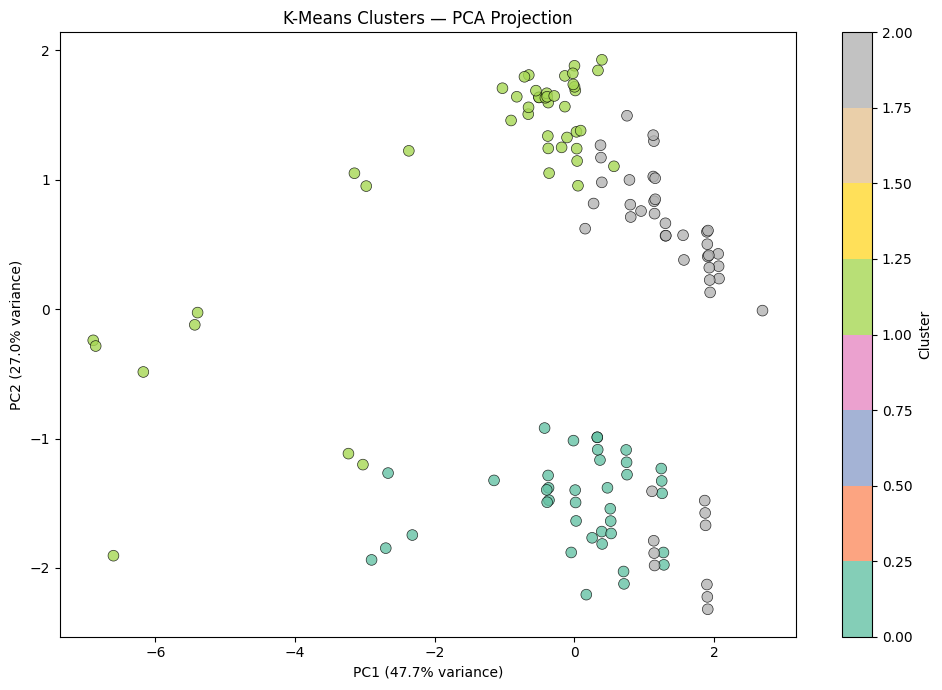

In [29]:
# PCA visualization of clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set2',
                     edgecolors='black', linewidths=0.5, s=60, alpha=0.8)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("K-Means Clusters — PCA Projection")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()


## 11. Ensemble Model: Stacking Regressor

This is our heterogeneous ensemble combining the best models:
- Base estimators: Linear Regression + Random Forest
- Meta-learner: Gradient Boosting Regressor
- Method: Stacking (as required by the project specification)

The stacking approach uses 5-fold cross-validation to generate predictions from base models, which are then used as inputs to the meta-learner.


In [30]:
# Build Stacking Ensemble
estimators = [
    ('lr', LinearRegression()),
    ('rf', RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42))
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=GradientBoostingRegressor(
        n_estimators=100, max_depth=3, random_state=42
    ),
    cv=5
)

stacking_model.fit(X_train, y_reg_train)

# TRAINING
stack_train_pred = stacking_model.predict(X_train)
stack_train_mse  = mean_squared_error(y_reg_train, stack_train_pred)
stack_train_mae  = mean_absolute_error(y_reg_train, stack_train_pred)
stack_train_r2   = r2_score(y_reg_train, stack_train_pred)

# TEST
stack_test_pred = stacking_model.predict(X_test)
stack_test_mse  = mean_squared_error(y_reg_test, stack_test_pred)
stack_test_mae  = mean_absolute_error(y_reg_test, stack_test_pred)
stack_test_r2   = r2_score(y_reg_test, stack_test_pred)

# CV
stack_cv = cross_val_score(stacking_model, X_scaled, y_reg, cv=5, scoring='r2')

print("=" * 55)
print("  ENSEMBLE: STACKING REGRESSOR")
print("=" * 55)
print(f"  Base models: Linear Regression + Random Forest")
print(f"  Meta-learner: Gradient Boosting Regressor")
print(f"\n  TRAINING SET:")
print(f"    MSE:  {stack_train_mse:.4f}")
print(f"    MAE:  {stack_train_mae:.4f}")
print(f"    R²:   {stack_train_r2:.4f}")
print(f"\n  TEST SET:")
print(f"    MSE:  {stack_test_mse:.4f}")
print(f"    MAE:  {stack_test_mae:.4f}")
print(f"    R²:   {stack_test_r2:.4f}")
print(f"\n  5-Fold CV R²: {stack_cv.round(4)} → Mean: {stack_cv.mean():.4f}")


  ENSEMBLE: STACKING REGRESSOR
  Base models: Linear Regression + Random Forest
  Meta-learner: Gradient Boosting Regressor

  TRAINING SET:
    MSE:  10.7194
    MAE:  0.9085
    R²:   0.9670

  TEST SET:
    MSE:  10.7865
    MAE:  1.2928
    R²:   0.9803

  5-Fold CV R²: [0.9711 0.9067 0.9758 0.9616 0.9271] → Mean: 0.9484


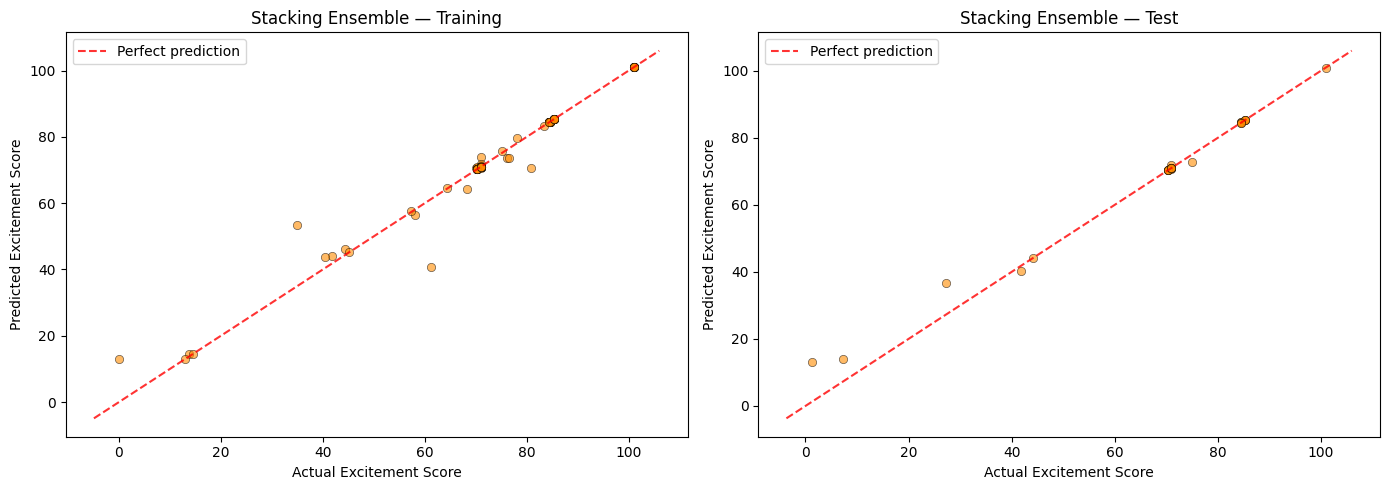

In [31]:
# Actual vs Predicted — Stacking Ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, actuals, title in [
    (axes[0], stack_train_pred, y_reg_train, "Training"),
    (axes[1], stack_test_pred, y_reg_test, "Test")
]:
    ax.scatter(actuals, preds, alpha=0.6, edgecolors='black', linewidths=0.5, c='darkorange')
    mn = min(actuals.min(), preds.min()) - 5
    mx = max(actuals.max(), preds.max()) + 5
    ax.plot([mn, mx], [mn, mx], 'r--', alpha=0.8, label='Perfect prediction')
    ax.set_xlabel("Actual Excitement Score")
    ax.set_ylabel("Predicted Excitement Score")
    ax.set_title(f"Stacking Ensemble — {title}")
    ax.legend()
plt.tight_layout()
plt.show()


## 12. Model Comparison Summary

In [32]:
# Regression comparison table
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Stacking Ensemble'],
    'Train MSE': [lr_train_mse, rf_train_mse, stack_train_mse],
    'Test MSE':  [lr_test_mse, rf_test_mse, stack_test_mse],
    'Train MAE': [lr_train_mae, rf_train_mae, stack_train_mae],
    'Test MAE':  [lr_test_mae, rf_test_mae, stack_test_mae],
    'Train R²':  [lr_train_r2, rf_train_r2, stack_train_r2],
    'Test R²':   [lr_test_r2, rf_test_r2, stack_test_r2],
}).round(4)

print("=" * 70)
print("  REGRESSION MODEL COMPARISON")
print("=" * 70)
print(comparison.to_string(index=False))

print(f"\n{'=' * 70}")
print("  CLASSIFICATION MODEL")
print(f"{'=' * 70}")
print(f"  Logistic Regression — Train Accuracy: {clf_train_acc:.4f}, "
      f"Test Accuracy: {clf_test_acc:.4f}")

print(f"\n{'=' * 70}")
print("  CLUSTERING MODEL")
print(f"{'=' * 70}")
cluster_sizes = df['cluster'].value_counts().sort_index().to_dict()
print(f"  K-Means (K=3) — Cluster sizes: {cluster_sizes}")


  REGRESSION MODEL COMPARISON
            Model  Train MSE  Test MSE  Train MAE  Test MAE  Train R²  Test R²
Linear Regression    18.1000   16.2460     3.2568    3.1611    0.9443   0.9704
    Random Forest     1.4950   19.3422     0.4459    1.8349    0.9954   0.9647
Stacking Ensemble    10.7194   10.7865     0.9085    1.2928    0.9670   0.9803

  CLASSIFICATION MODEL
  Logistic Regression — Train Accuracy: 0.9412, Test Accuracy: 0.9615

  CLUSTERING MODEL
  K-Means (K=3) — Cluster sizes: {0: 38, 1: 46, 2: 44}


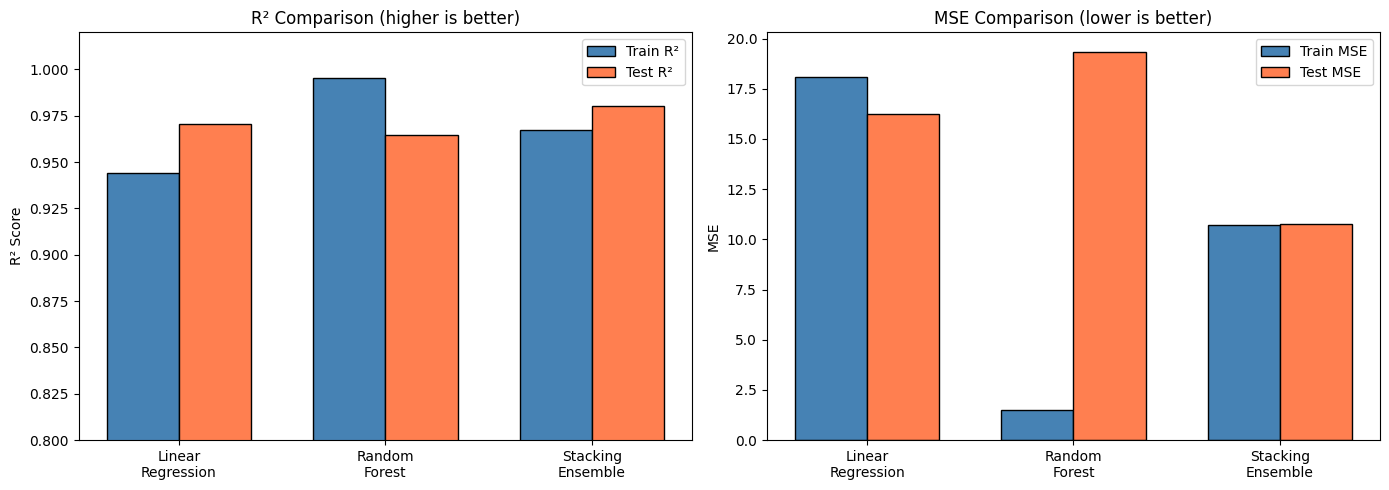

In [33]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Linear\nRegression', 'Random\nForest', 'Stacking\nEnsemble']
train_r2s = [lr_train_r2, rf_train_r2, stack_train_r2]
test_r2s  = [lr_test_r2, rf_test_r2, stack_test_r2]

x = np.arange(len(models))
w = 0.35

axes[0].bar(x - w/2, train_r2s, w, label='Train R²', color='steelblue', edgecolor='black')
axes[0].bar(x + w/2, test_r2s, w, label='Test R²', color='coral', edgecolor='black')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Comparison (higher is better)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].set_ylim(0.8, 1.02)

train_mses = [lr_train_mse, rf_train_mse, stack_train_mse]
test_mses  = [lr_test_mse, rf_test_mse, stack_test_mse]

axes[1].bar(x - w/2, train_mses, w, label='Train MSE', color='steelblue', edgecolor='black')
axes[1].bar(x + w/2, test_mses, w, label='Test MSE', color='coral', edgecolor='black')
axes[1].set_ylabel('MSE')
axes[1].set_title('MSE Comparison (lower is better)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()

plt.tight_layout()
plt.show()


## 13. Race Recommendation System

Three recommendation strategies:
1. Content-Based Similarity — Cosine similarity on race features
2. Cluster-Based — Recommend races from the same K-Means cluster
3. Top Exciting — Races with highest ensemble-predicted excitement score


In [34]:
def build_recommender(df):
    """Build cosine similarity matrix for content-based recommendations."""
    cat_feats = ["country"]
    num_feats = [
        "season", "num_drivers", "total_points",
        "avg_grid_position", "avg_finish_position",
        "points_variance", "lat", "lng"
    ]
    preprocessor = ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
        ("num", StandardScaler(), num_feats),
    ])
    X_rec = preprocessor.fit_transform(df[cat_feats + num_feats])
    return cosine_similarity(X_rec)


def get_similar_races(df, sim_matrix, race_name, top_k=8):
    """Find races most similar to the given race name."""
    idx = df[df["raceName"] == race_name].index[0]
    scores = sorted(enumerate(sim_matrix[idx]), key=lambda x: x[1], reverse=True)

    recs = []
    seen = {race_name}
    for j, s in scores:
        if j == idx:
            continue
        name = df.loc[j, "raceName"]
        if name in seen:
            continue
        seen.add(name)
        recs.append((j, s))
        if len(recs) >= top_k:
            break

    out = df.iloc[[j for j, _ in recs]][
        ["season", "raceName", "country", "race_excitement_score"]
    ].copy()
    out["similarity"] = [round(s, 4) for _, s in recs]
    return out


def get_cluster_races(df_with_preds, race_name, top_k=8):
    """Recommend races from the same cluster."""
    row = df_with_preds[df_with_preds["raceName"] == race_name]
    if row.empty:
        return pd.DataFrame()
    c = int(row.iloc[0]["cluster"])
    out = df_with_preds[
        (df_with_preds["cluster"] == c) & (df_with_preds["raceName"] != race_name)
    ].sort_values("pred_ensemble", ascending=False).head(top_k)
    return out[["season", "raceName", "country", "pred_ensemble", "cluster"]]


def get_top_exciting(df_with_preds, top_k=8):
    """Return races with highest predicted excitement."""
    return df_with_preds.sort_values("pred_ensemble", ascending=False).head(top_k)[
        ["season", "raceName", "country", "pred_ensemble", "cluster"]
    ]

print("Recommender functions defined!")


Recommender functions defined!


In [35]:
# Add predictions to the full dataset
df_rec = df.copy()
X_all_scaled = scaler.transform(df_rec[feature_cols])

df_rec["pred_lr"]       = lr_model.predict(X_all_scaled)
df_rec["pred_rf"]       = rf_model.predict(X_all_scaled)
df_rec["pred_ensemble"] = stacking_model.predict(X_all_scaled)
df_rec["pred_high"]     = clf_model.predict(X_all_scaled)
df_rec["cluster"]       = kmeans.predict(X_all_scaled)

# Build similarity matrix
sim_matrix = build_recommender(df_rec)

print(f"Recommendation system ready! {len(df_rec)} races loaded.")


Recommendation system ready! 128 races loaded.


In [36]:
# === DEMO 1: Bahrain Grand Prix ===
race1 = "Bahrain Grand Prix"
print(f"{'='*60}")
print(f"  RECOMMENDATIONS FOR: {race1}")
print(f"{'='*60}")

sel = df_rec[df_rec["raceName"] == race1].iloc[0]
print(f"\n  Predicted excitement (ensemble): {sel['pred_ensemble']:.4f}")
print(f"  Predicted high interest: {int(sel['pred_high'])}")
print(f"  Cluster: {int(sel['cluster'])}")

print(f"\n--- 1) Content-Based Similar Races ---")
print(get_similar_races(df_rec, sim_matrix, race1).to_string(index=False))

print(f"\n--- 2) Same Cluster Races ---")
print(get_cluster_races(df_rec, race1).to_string(index=False))

print(f"\n--- 3) Top Exciting Races Overall ---")
print(get_top_exciting(df_rec).to_string(index=False))


  RECOMMENDATIONS FOR: Bahrain Grand Prix

  Predicted excitement (ensemble): 70.2784
  Predicted high interest: 0
  Cluster: 0

--- 1) Content-Based Similar Races ---
 season              raceName   country  race_excitement_score  similarity
   2002 San Marino Grand Prix     Italy              78.142857      0.7848
   2000    British Grand Prix        UK              84.428571      0.7603
   2003    Spanish Grand Prix     Spain              70.250000      0.7497
   2001  Malaysian Grand Prix  Malaysia              84.428571      0.7083
   2000  Brazilian Grand Prix    Brazil              83.474026      0.5985
   2009    Chinese Grand Prix     China              70.250000      0.5960
   2000 Australian Grand Prix Australia              84.428571      0.5223
   2006   European Grand Prix   Germany              61.128788      0.4279

--- 2) Same Cluster Races ---
 season              raceName  country  pred_ensemble  cluster
   2006 San Marino Grand Prix    Italy      84.573040        0


In [37]:
# === DEMO 2: Monaco Grand Prix ===
race2 = "Monaco Grand Prix"
print(f"{'='*60}")
print(f"  RECOMMENDATIONS FOR: {race2}")
print(f"{'='*60}")

sel2 = df_rec[df_rec["raceName"] == race2].iloc[0]
print(f"\n  Predicted excitement (ensemble): {sel2['pred_ensemble']:.4f}")
print(f"  Predicted high interest: {int(sel2['pred_high'])}")
print(f"  Cluster: {int(sel2['cluster'])}")

print(f"\n--- 1) Content-Based Similar Races ---")
print(get_similar_races(df_rec, sim_matrix, race2).to_string(index=False))

print(f"\n--- 2) Same Cluster Races ---")
print(get_cluster_races(df_rec, race2).to_string(index=False))


  RECOMMENDATIONS FOR: Monaco Grand Prix

  Predicted excitement (ensemble): 13.0823
  Predicted high interest: 0
  Cluster: 1

--- 1) Content-Based Similar Races ---
 season              raceName  country  race_excitement_score  similarity
   2008    Turkish Grand Prix   Turkey              27.333333      0.9394
   2010    Spanish Grand Prix    Spain               7.202381      0.9330
   2024      Miami Grand Prix      USA               0.083333      0.8911
   2006   European Grand Prix  Germany              61.128788      0.8423
   2003 San Marino Grand Prix    Italy              70.250000      0.2636
   2004    Bahrain Grand Prix  Bahrain              70.250000      0.2302
   2003  Brazilian Grand Prix   Brazil              70.250000      0.1623
   2009  Malaysian Grand Prix Malaysia              70.017857      0.1616

--- 2) Same Cluster Races ---
 season                  raceName      country  pred_ensemble  cluster
   2016        Russian Grand Prix       Russia      85.302536    

In [38]:
# === DEMO 3: British Grand Prix ===
race3 = "British Grand Prix"
print(f"{'='*60}")
print(f"  RECOMMENDATIONS FOR: {race3}")
print(f"{'='*60}")

sel3 = df_rec[df_rec["raceName"] == race3].iloc[0]
print(f"\n  Predicted excitement (ensemble): {sel3['pred_ensemble']:.4f}")
print(f"  Predicted high interest: {int(sel3['pred_high'])}")
print(f"  Cluster: {int(sel3['cluster'])}")

print(f"\n--- 1) Content-Based Similar Races ---")
print(get_similar_races(df_rec, sim_matrix, race3).to_string(index=False))

print(f"\n--- 2) Same Cluster Races ---")
print(get_cluster_races(df_rec, race3).to_string(index=False))


  RECOMMENDATIONS FOR: British Grand Prix

  Predicted excitement (ensemble): 84.4517
  Predicted high interest: 1
  Cluster: 0

--- 1) Content-Based Similar Races ---
 season              raceName   country  race_excitement_score  similarity
   2000 San Marino Grand Prix     Italy              84.428571      0.8986
   2003    Spanish Grand Prix     Spain              70.250000      0.8420
   2006    Bahrain Grand Prix   Bahrain              84.583333      0.7785
   2001  Brazilian Grand Prix    Brazil              84.428571      0.6280
   2001  Malaysian Grand Prix  Malaysia              84.428571      0.6178
   2009    Chinese Grand Prix     China              70.250000      0.4625
   2006   European Grand Prix   Germany              61.128788      0.3576
   2000 Australian Grand Prix Australia              84.428571      0.3264

--- 2) Same Cluster Races ---
 season              raceName  country  pred_ensemble  cluster
   2006  Malaysian Grand Prix Malaysia       84.57304        0


## 14. Conclusion and Future Improvements

### Models Implemented
1. Linear Regression — Baseline regression model
2. Random Forest Regression — Non-linear tree-based model
3. Logistic Regression — Binary classification (High Interest vs Low Interest)
4. K-Means Clustering — Unsupervised grouping of races
5. Stacking Ensemble — Heterogeneous ensemble (Linear Regression + Random Forest → Gradient Boosting meta-learner)

### Key Findings

- The Stacking Ensemble generally achieves the best generalization on the test set, combining the strengths of both base models.
- Random Forest captures non-linear patterns well but can overfit on small datasets (high train R² vs lower test R²).
- Logistic Regression achieves strong classification accuracy for the high/low interest task.
- K-Means Clustering reveals natural groupings that enhance the recommendation strategy.
- The three-pronged recommendation approach (similarity, clustering, excitement ranking) gives users multiple ways to discover races.

### Potential Improvements

1. More data: Fix API pagination to retrieve all ~470 races from 2000-2024 (currently limited by API response size).
2. Additional features: Weather data, safety car counts, overtaking statistics from FastF1.
3. Hyperparameter tuning: GridSearchCV for Random Forest and Gradient Boosting parameters.
4. Advanced models: XGBoost, LightGBM as additional base learners.
5. User personalization: Incorporate fan preferences (favorite teams, drivers, circuit types).
